In [68]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from globals import behavDir
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
plt.style.use('default')

### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [69]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
behavDir = 'Behavioural'
recDir = 'Recordings'
cfg = mat73.loadmat(os.path.join(baseDir, lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

freqs = ['delta', 'theta', 'alpha-beta', 'gamma']
recordings = {
            'Malfoy': {
                'PMd': [19, 20, 21, 22, 23, 24],
                'M1': [12, 13, 25, 27, 28],
                'S1': [11, 15, 16, 26, 27, 28]
            },
            'Pert': {
                'PMd': [4, 6, 7, 10, 20],
                'M1': [2, 3, 14, 20],
                'S1': [15]
            }
        }

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre) + 5
t = np.concatenate((t_cue, t_pert))

monkey = ['Malfoy', 'Pert']

rois = ['PMd', 'M1', 'S1']
freq = freq_masks['alpha-beta']

var_expl = {"lfp": [], "spk": [], 'roi': []}  # each becomes list over rois
kin = {"elbow": [], "prob": [], 'cond': [], 'rec': [], 'roi': []}
corr = {"lfp": [], "spk": [], 'roi': []}
epoch = 'plan'
for roi in rois:
    for mon in monkey:
        for rec in recordings[mon][roi]:
            theta_lfp_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.lfp.component.{roi}.{epoch}-{rec}.npy'))
            theta_spk_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.spk.component.{roi}.{epoch}-{rec}.npy'))
            elb = np.load(os.path.join(baseDir, behavDir, mon, f'kin_aligned-{rec}.npy'))
            tinfo = pd.read_csv(os.path.join(baseDir, recDir, mon, f'trial_info-{rec}.tsv'), sep='\t')
            tinfo = tinfo[(tinfo['isCatch']==0) & (tinfo['AdaptationBlock']==0)]
            mapping = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
            tinfo.cond = tinfo.cond.map(mapping)
            kin['elbow'].append(elb.T)
            kin['prob'].append(tinfo['prob'])
            kin['cond'].append(tinfo['cond'])
            kin['rec'].extend([f'{mon}-{rec}'] * tinfo['cond'].shape[0])
            kin['roi'].extend([roi] * tinfo['cond'].shape[0])
            var_expl["lfp"].append(np.exp(theta_lfp_comp[...,:-1]))
            var_expl["spk"].append(np.exp(theta_spk_comp[:, :-1]))
            var_expl["roi"].append(roi)

for m in monkey:
    for r in recordings[m]['M1']:
        theta_lfp_feat = np.load(os.path.join(baseDir, pcmDir, m, f'theta_in.lfp.feature.M1.exec-{r}.npy'))
        theta2 = theta_lfp_feat ** 2
        covariance = theta_lfp_feat[..., 1] * theta_lfp_feat[..., 2]
        stds = np.sqrt((theta2[..., 0] + theta2[..., 1]) * theta2[..., 2])
        correlation = covariance / stds
        corr['lfp'].append(np.array([theta2[..., 0] + theta2[..., 1], theta2[..., 2], covariance]))
        theta_spk_feat = np.load(os.path.join(baseDir, pcmDir, m, f'theta_in.spk.feature.M1.exec-{r}.npy'))
        theta2 = theta_spk_feat ** 2
        covariance = theta_spk_feat[..., 1] * theta_spk_feat[..., 2]
        stds = np.sqrt((theta2[..., 0] + theta2[..., 1]) * theta2[..., 2])
        correlation = covariance / stds
        corr['spk'].append(np.array([theta2[..., 0] + theta2[..., 1], theta2[..., 2], covariance]))

        corr['roi'].append('M1')

kin = xr.DataArray(data=np.vstack(kin['elbow']),
                    dims=('trial', 'time'),
                    coords={
                        'cond': ('trial', np.hstack(kin['cond'])),
                        'prob': ('trial', np.hstack(kin['prob'])),
                        'rec': ('trial', np.hstack(kin['rec'])),
                        'roi': ('trial', np.hstack(kin['roi'])),})
var_expl_lfp_plan = xr.DataArray(data=np.stack(var_expl["lfp"]),
                   dims=('roi', 'freq', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'freq': foi,
                       'time': t,
                       'model': ['cue', 'uncertainty']})
var_expl_spk_plan = xr.DataArray(data=np.stack(var_expl["spk"]),
                   dims=('roi', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'time': t,
                       'model': ['cue', 'uncertainty']})
corr_lfp = xr.DataArray(data=np.stack(corr["lfp"]),
                   dims=('roi', 'meas', 'freq', 'time', ),
                   coords={'roi': corr['roi'],
                       'freq': foi,
                       'time': t,
                       'meas': ['var_dir', 'var_cue', 'cov']})
corr_spk = xr.DataArray(data=np.stack(corr["spk"]),
                   dims=('roi', 'meas', 'time', ),
                   coords={
                       'roi': corr['roi'],
                       'time': t,
                       'meas': ['var_dir', 'var_cue', 'cov']})

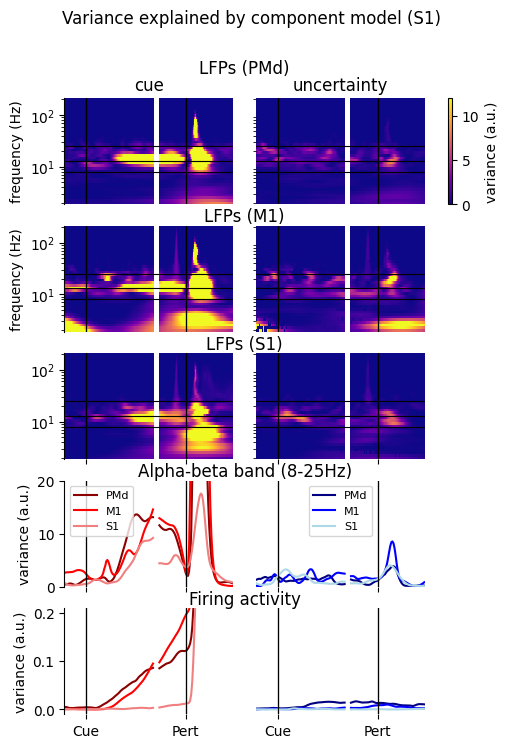

In [70]:
fig, axs_ = plt.subplots(5, 3, sharex='col', figsize=(5, 8), gridspec_kw={"width_ratios": [80, 80, 2]})

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

for r in range(2):
    axs[r, 1].sharey(axs[r, 0])
for r in range(2, 4):
    axs[r, 1].sharey(axs[r, 0])

vmin, vmax = 0, 12
color = [['darkred', 'navy'], ['red', 'blue'],  ['lightcoral', 'lightblue']]
label = ['cue', 'uncertainty']
for i in range(2):
    for r, roi in enumerate(rois):
        tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=label[i]).mean(dim='roi').values
        tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=label[i]).mean(dim='roi').values
        h = axs[r, i].pcolormesh(t_cue, foi, tf1, vmin=vmin, vmax=vmax, cmap='plasma')
        axs[r, i].pcolormesh(t_pert, foi, tf2, vmin=vmin, vmax=vmax, cmap='plasma')
        axs[r, i].set_yscale('log')
        axs[r, i].axhline(8, color='k', lw='.8')
        axs[r, i].axhline(13, color='k', lw='.8')
        axs[r, i].axhline(25, color='k', lw='.8')
        band1 = var_expl_lfp_plan.sel(roi=roi, freq=slice(8, 25), time=slice(0, cuePost-1), model=label[i]).mean(dim=('roi', 'freq')).values
        band2 = var_expl_lfp_plan.sel(roi=roi, freq=slice(8, 25), time=slice(pertPre, None), model=label[i]).mean(dim=('roi', 'freq')).values
        axs[3, i].plot(t_cue, band1, color=color[r][i], label=roi)
        axs[3, i].plot(t_pert, band2, color=color[r][i])
        axs[3, i].legend(fontsize=8)
        axs[3, i].set_ylim(-.01, 20)
        act1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model=label[i]).mean(dim='roi').values
        act2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model=label[i]).mean(dim='roi').values
        axs[4, i].plot(t_cue, act1, color=color[r][i])
        axs[4, i].plot(t_pert, act2, color=color[r][i])
        axs[4, i].set_ylim(-.01, .21)
        for j in range(5):
            axs[j, i].axvline(cueIdx, color='k', lw='.8')
            # axs[j, i].axvline(cueIdx + 16, color='k', lw='.8', ls=':')
            axs[j, i].axvline(pertIdx, color='k', lw='.8')
            if j < 2:
                axs[j, i].tick_params(bottom=False, labelbottom=False)
            else:
                axs[j, i].set_xticks([cueIdx, pertIdx])
                axs[j, i].set_xticklabels(['Cue', 'Pert'])
            if i==0:
                axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
            else:
                axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
                axs[j, i].tick_params(left=False, labelleft=False)

axs[0, 0].set_title('cue')
axs[0, 1].set_title('uncertainty')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('frequency (Hz)')
axs[3, 0].set_ylabel('variance (a.u.)')
axs[4, 0].set_ylabel('variance (a.u.)')

x0 = axs[1, 0].get_position().x0
x1 = axs[1, 1].get_position().x1
xc = (x0 + x1) / 2
fig.text(xc, axs[0, 0].get_position().y1, "LFPs (PMd)\n", ha="center", va="bottom", fontsize=12)
fig.text(xc, axs[1, 0].get_position().y1, "LFPs (M1)", ha="center", va="bottom", fontsize=12)
fig.text(xc, axs[2, 0].get_position().y1, "LFPs (S1)", ha="center", va="bottom", fontsize=12)
fig.text(xc, axs[3, 0].get_position().y1, "Alpha-beta band (8-25Hz)", ha="center", va="bottom", fontsize=12)
fig.text(xc, axs[4, 0].get_position().y1, "Firing activity", ha="center", va="bottom", fontsize=12)

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Variance explained by component model ({roi})', va='center')
# fig.tight_layout()

plt.show()

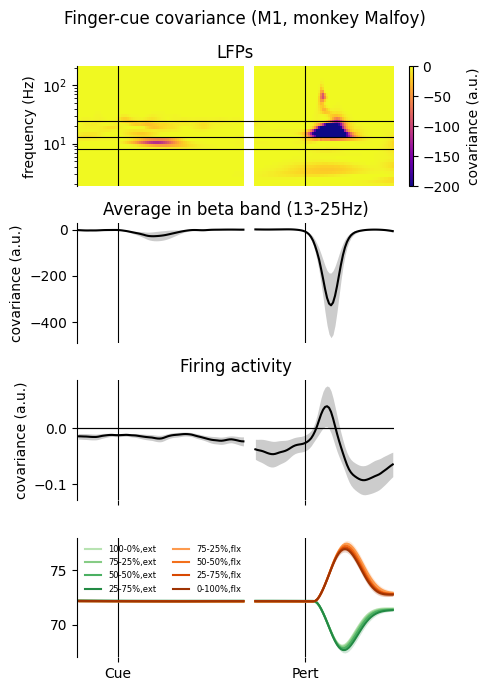

In [71]:
fig, axs_ = plt.subplots(4, 2, sharex='col', figsize=(5, 7), gridspec_kw={"width_ratios": [80, 1]})

axs = axs_[:, 0]
ax_c = axs_[:, 1]

vmin, vmax = -200, 0

h = axs[0].pcolormesh(t_cue, foi, corr_lfp[:, -1, :, :cuePost].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
axs[0].pcolormesh(t_pert, foi, corr_lfp[:, -1, :, pertPre:].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
axs[0].set_yscale('log')
axs[0].axhline(8, color='k', lw='.8')
axs[0].axhline(13, color='k', lw='.8')
axs[0].axhline(24, color='k', lw='.8')
y_lfp = corr_lfp[:, -1, freq].mean(axis=(0, 1))
yerr_lfp = corr_lfp[:, -1, freq].mean(axis=1).std(axis=0) / np.sqrt(corr_lfp.shape[0])
y_spk = corr_spk[:, -1].mean(axis=0)
yerr_spk = corr_spk[:, -1].std(axis=0) / np.sqrt(corr_spk.shape[0])
axs[1].plot(t_cue, y_lfp[:cuePost], color='k')
axs[1].plot(t_pert, y_lfp[pertPre:], color='k')
axs[1].fill_between(t_cue, y_lfp[:cuePost] - yerr_lfp[:cuePost], y_lfp[:cuePost] + yerr_lfp[:cuePost], alpha=.2, color='k', lw=0)
axs[1].fill_between(t_pert, y_lfp[pertPre:] - yerr_lfp[pertPre:], y_lfp[pertPre:] + yerr_lfp[pertPre:], alpha=.2, color='k', lw=0)
axs[2].plot(t_cue, y_spk[:cuePost], color='k')
axs[2].plot(t_pert, y_spk[pertPre:], color='k')
axs[2].fill_between(t_cue, y_spk[:cuePost] - yerr_spk[:cuePost], y_spk[:cuePost] + yerr_spk[:cuePost], alpha=.2, color='k', lw=0)
axs[2].fill_between(t_pert, y_spk[pertPre:] - yerr_spk[pertPre:], y_spk[pertPre:] + yerr_spk[pertPre:], alpha=.2, color='k', lw=0)
axs[2].axhline(0, color='k', lw='.8')
axs[2].axhline(0, color='k', lw='.8')
for j in range(4):
    axs[j].axvline(cueIdx, color='k', lw='.8')
    axs[j].axvline(pertIdx, color='k', lw='.8')
    if j < 2:
        axs[j].tick_params(bottom=False, labelbottom=False)
    else:
        axs[j].set_xticks([cueIdx, pertIdx])
        axs[j].set_xticklabels(['Cue', 'Pert'])
    axs[j].spines[['top', 'right', 'bottom']].set_visible(False)

axs[0].set_title('LFPs')
axs[0].set_ylabel('frequency (Hz)')
axs[1].set_ylabel('covariance (a.u.)')
axs[1].set_title('Average in beta band (13-25Hz)')
axs[2].set_ylabel('covariance (a.u.)')
axs[2].set_title('Firing activity')

fig.colorbar(h, cax=ax_c[0], label='covariance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

kin_grouped = kin.groupby(['cond', 'rec']).mean()
bs = kin_grouped[:cuePost, :, :].mean()
kinM = kin_grouped.mean(axis=-1) #- bs
kinErr = (kin_grouped.std(axis=-1) / np.sqrt(kin_grouped.shape[-1])) #- bs
for i in range(kin_grouped.shape[1]):
    axs[3].plot(t_cue, kinM[:cuePost, i], color=list(colour_mapping.values())[5+i], label=list(colour_mapping.keys())[5+i])
    axs[3].fill_between(t_cue, kinM[:cuePost, i] - kinErr[:cuePost, i], kinM[:cuePost, i] + kinErr[:cuePost, i], color=list(colour_mapping.values())[5+i], lw=0, alpha=.2)
    axs[3].plot(t_pert, kinM[pertPre:, i], color=list(colour_mapping.values())[5+i])
    axs[3].fill_between(t_pert, kinM[pertPre:, i] - kinErr[pertPre:, i], kinM[pertPre:, i] + kinErr[pertPre:, i], color=list(colour_mapping.values())[5+i], lw=0, alpha=.2)

axs[3].legend(loc='upper left', frameon=False, fontsize=6, ncol=2)
axs[3].set_ylim(67, 78)

fig.suptitle(f'Finger-cue covariance (M1, monkey {monkey[0]})')
fig.tight_layout()

plt.show()

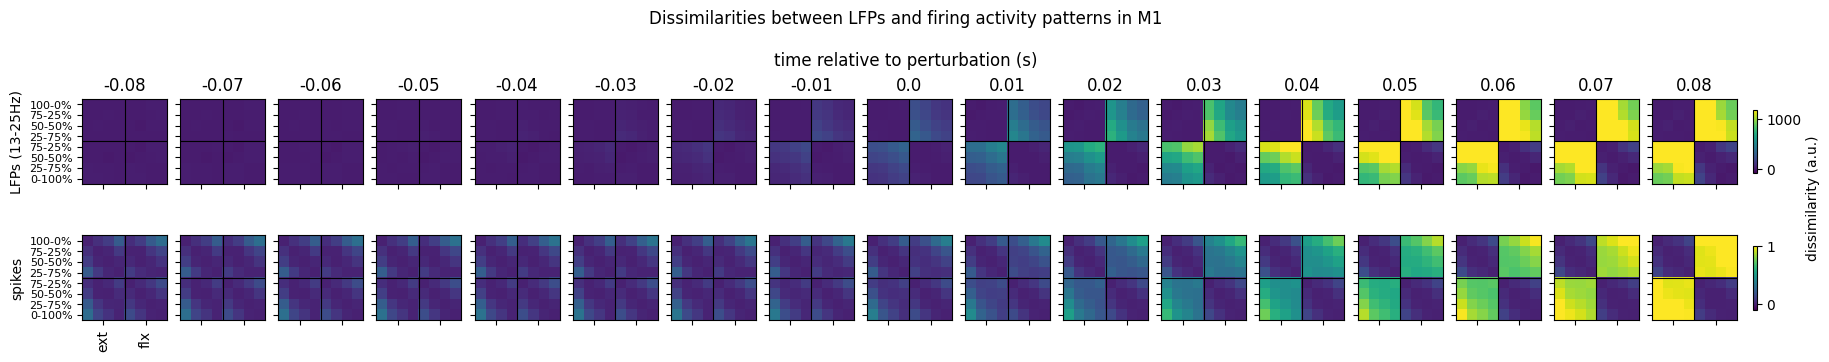

In [72]:
D_lfp, D_spk = [], []
for mon in monkey:
    for rec in recordings[mon]['M1']:
        G_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.lfp.M1.exec-{rec}.npy'))
        freq = freq_masks['beta']
        G_lfp = G_lfp[freq].mean(axis=0)
        G_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.spk.M1.exec-{rec}.npy'))
        D_lfp.append(pcm.G_to_dist(G_lfp))
        D_spk.append(pcm.G_to_dist(G_spk))
D_lfp, D_spk = np.array(D_lfp).mean(axis=0), np.array(D_spk).mean(axis=0)
n_timep = 17
timep = np.linspace(-8, 8, n_timep, dtype=int)
fig, axs = plt.subplots(2, n_timep, figsize=(18, 3.5), sharex=True, sharey=True, constrained_layout=True)
for i in range(n_timep):
    ax = axs[:, i]
    ax[0].imshow(D_lfp[pertIdx+timep[i]], vmin=-100, vmax=1200)
    ax[1].imshow(D_spk[pertIdx+timep[i]], vmin=-.1, vmax=1)
    ax[0].set_title(timep[i] / 100)
    ax[0].set_yticks(np.arange(0, 8))
    ax[0].set_xticks(np.arange(1.5, 9.5, 4))
    ax[1].tick_params(labelbottom=False, labelleft=False)
    ax[0].tick_params(labelleft=False)
    for j in range(2):
        ax[j].axhline(3.5, color='k', lw='.8')
        ax[j].axvline(3.5, color='k', lw='.8')

axs[0, 0].set_ylabel('LFPs (13-25Hz)')
axs[1, 0].set_ylabel('spikes')
axs[0, 0].tick_params(labelleft=True)
axs[0, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_xticklabels(['ext', 'flx'], rotation=90)
axs[1, 0].tick_params(labelbottom=True, labelleft=True)
fig.suptitle('Dissimilarities between LFPs and firing activity patterns in M1\n\ntime relative to perturbation (s)')
cax = axs[0, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
cax = axs[1, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
fig.text(1, .45, 'dissimilarity (a.u.)', va='center', rotation='vertical', ha='left')

plt.show()

0
group estimate:0.09668365908355613 central 90% CI for r: [-0.180, 0.365]
1
group estimate:0.6115790069919195 central 90% CI for r: [0.450, 0.724]


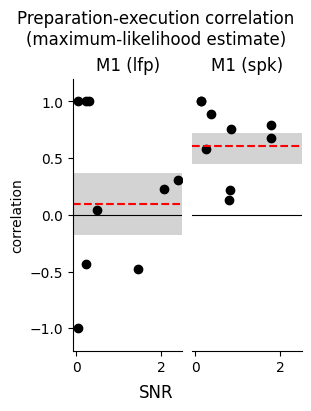

In [73]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
dtype = ['lfp', 'spk']
roi = 'M1'

fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))

for d, dt in enumerate(dtype):
    print(d)
    f = open(os.path.join(baseDir, pcmDir, f'theta_in.{dt}.corr_plan-exec.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(baseDir, pcmDir, f'r_bootstrap.{dt}.corr_plan-exec.{roi}.npy'))
    f = open(os.path.join(baseDir, pcmDir, f'theta_gr.{dt}.corr_plan-exec.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, d, Mflex, theta, theta_g, r_bootstrap)
    axs[d].set_title(f'{roi} ({dt})')

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Preparation-execution correlation\n(maximum-likelihood estimate)')

plt.show()


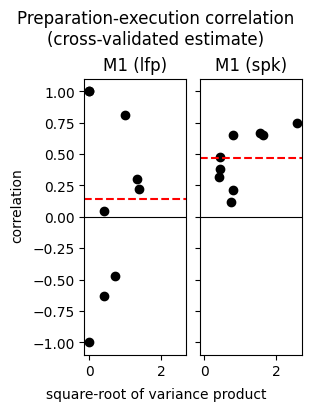

In [74]:
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))
for d, dt in enumerate(dtype):
    ax = axs[d]
    G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.{dt}.corr_plan-exec.M1.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2) + 1e-6, -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(f'M1 ({dt})')

fig.suptitle('Preparation-execution correlation\n(cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

0
group estimate:-0.8501910743825125 central 90% CI for r: [-1.000, -0.536]
1
group estimate:0.45478092194988246 central 90% CI for r: [0.325, 0.554]


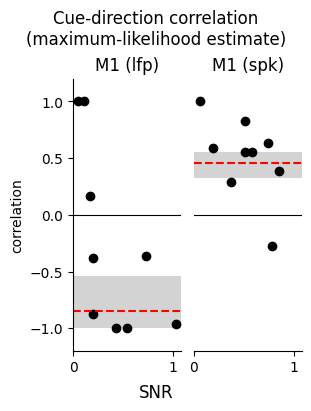

In [83]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
dtype = ['lfp', 'spk']
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))

for d, dt in enumerate(dtype):
    print(d)
    f = open(os.path.join(baseDir, pcmDir, f'theta_in.{dt}.corr_cue-dir.M1.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(baseDir, pcmDir, f'r_bootstrap.{dt}.corr_cue-dir.M1.npy'))
    f = open(os.path.join(baseDir, pcmDir, f'theta_gr.{dt}.corr_cue-dir.M1.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, d, Mflex, theta, theta_g, r_bootstrap)
    axs[d].set_title(f'M1 ({dt})')

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-direction correlation\n(maximum-likelihood estimate)')

plt.show()


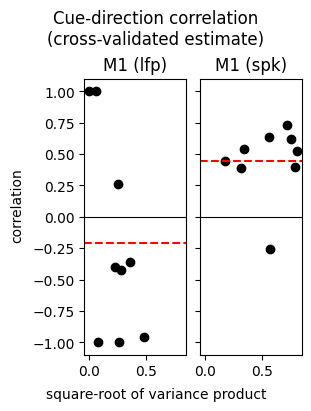

In [76]:
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))
for d, dt in enumerate(dtype):
    ax = axs[d]
    G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.{dt}.corr_cue-dir.M1.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2) + 1e-6, -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(f'M1 ({dt})')

fig.suptitle('Cue-direction correlation\n(cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()

slope: 3.130196495367302, p = 0.159
intercept: 0.18993644035457674, p_intercept = 0.348
R2 = 0.262


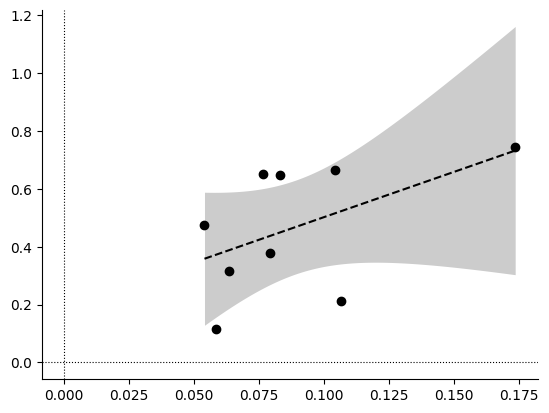

In [77]:
from vis import plot_correlation

rois_tmp = ['M1']
corr, kin_pre = [], []
for roi in rois_tmp:
    G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.spk.corr_plan-exec.{roi}.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr.extend(np.clip(cov / np.sqrt(var1 * var2) + 1e-6, -1, 1))

    kin_tmp = kin.where((kin['roi']==roi), drop=True)
    kin_grouped = kin_tmp.groupby(['rec', 'prob']).mean()

    mask_plan = {'ext': np.array([1, 1, 0, 0, 0], dtype=bool),
                 'flx': np.array([0, 0, 0, 1, 1], dtype=bool)}

    kin_ext = kin_grouped[:, :, mask_plan['ext']].mean(axis=-1)
    kin_flx = kin_grouped[:, :, mask_plan['flx']].mean(axis=-1)
    kin_pre.extend(np.abs(kin_ext - kin_flx)[cuePost - 20:cuePost].mean(axis=0).values)

fig, ax = plt.subplots()

plot_correlation(fig, ax, 0,  np.array(kin_pre), np.array(corr),)

plt.show()

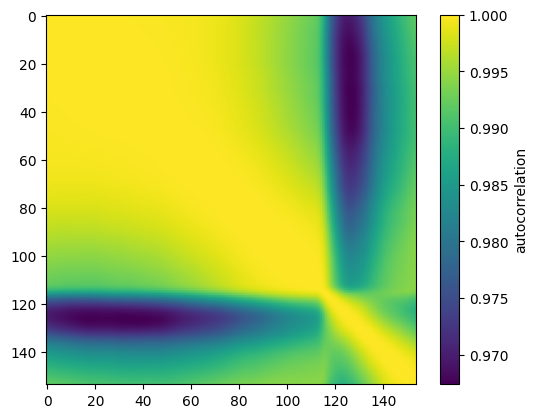

In [78]:
G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.spk.autocorr.M1.npy'))
cov = G[..., 0, 1]
var1 = np.clip(G[..., 0, 0], 0, None)
var2 = np.clip(G[..., 1, 1], 0, None)
autocorr = (cov / np.sqrt(var1 * var2)).mean(axis=(0, 1))
plt.imshow(autocorr)
plt.colorbar(label='autocorrelation')

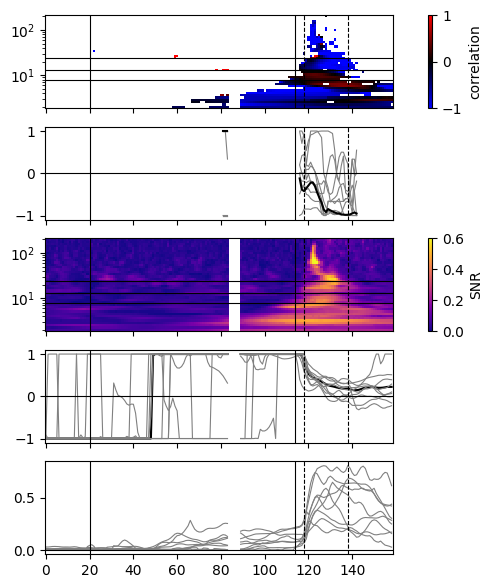

In [79]:
import matplotlib.colors as mcolors

freq = freq_masks['beta']

r_group_spk = np.load(os.path.join(baseDir, pcmDir, f'r_group.spk.corr_tf.M1.npy'))
SNR_spk = np.load(os.path.join(baseDir, pcmDir, f'SNR.spk.corr_tf.M1.npy'))
r_indiv_spk = np.load(os.path.join(baseDir, pcmDir, f'r_indiv.spk.corr_tf.M1.npy'))

r_group_lfp = np.load(os.path.join(baseDir, pcmDir, f'r_group.lfp.corr_tf.M1.npy'))
SNR_lfp = np.load(os.path.join(baseDir, pcmDir, f'SNR.lfp.corr_tf.M1.npy'))
r_indiv_lfp = np.load(os.path.join(baseDir, pcmDir, f'r_indiv.lfp.corr_tf.M1.npy'))

N = r_indiv_spk.shape[0]
thresh = .1
excl_spk = (SNR_spk > thresh).sum(axis=0) #np.isclose(np.abs(r_indiv_spk), 1).sum(axis=0)
# r_group_spk[excl_spk <= N//2] = np.nan
# r_indiv_spk[:, excl_spk <= N//2] = np.nan

excl_lfp = (SNR_lfp > thresh).sum(axis=0) # np.isclose(np.abs(r_indiv_lfp), 1).sum(axis=0)
r_group_lfp[excl_lfp <= N//2] = np.nan
r_indiv_lfp[:, excl_lfp <= N//2] = np.nan
r_group_beta = np.nanmean(r_group_lfp[freq], axis=0)
r_indiv_beta = np.nanmean(r_indiv_lfp[:, freq], axis=1)

fig, axs_ = plt.subplots(5, 2, sharex='col', figsize=(5, 7), gridspec_kw={"width_ratios": [80, 1]} )

axs = axs_[:, 0]
ax_c = axs_[:, 1]

cmap = mcolors.LinearSegmentedColormap.from_list("blue_black_red", ["blue", "black", "red"], N=256)

h = axs[0].pcolormesh(t_cue, foi, r_group_lfp[:, :cuePost], vmin=-1, vmax=1, cmap=cmap)
axs[0].pcolormesh(t_pert, foi, r_group_lfp[:, pertPre:], vmin=-1, vmax=1, cmap=cmap)
k = axs[2].pcolormesh(t_cue, foi, SNR_lfp[..., :cuePost].mean(axis=0), vmin=0, vmax=.6, cmap='plasma')
axs[2].pcolormesh(t_pert, foi, SNR_lfp[..., pertPre:].mean(axis=0), vmin=0, vmax=.6, cmap='plasma')
axs[0].set_yscale('log')
axs[2].set_yscale('log')
axs[1].plot(t_cue, r_group_beta[:cuePost], color='k', zorder=100)
axs[1].plot(t_pert, r_group_beta[pertPre:], color='k', zorder=100)
axs[1].plot(t_cue, r_indiv_beta[:, :cuePost].T, color='grey', lw=.8)
axs[1].plot(t_pert, r_indiv_beta[:, pertPre:].T, color='grey', lw=.8)
axs[3].plot(t_cue, r_group_spk[:cuePost], color='k')
axs[3].plot(t_pert, r_group_spk[pertPre:], color='k')
axs[3].plot(t_cue, r_indiv_spk[:, :cuePost].T, color='grey', lw=.8)
axs[3].plot(t_pert, r_indiv_spk[:, pertPre:].T, color='grey', lw=.8)
axs[4].plot(t_cue, SNR_spk[:, :cuePost].T, color='grey', lw=.8)
axs[4].plot(t_pert, SNR_spk[:, pertPre:].T, color='grey', lw=.8)

for i in [0, 2]:
    axs[i].axhline(8, color='k', lw='.8')
    axs[i].axhline(13, color='k', lw='.8')
    axs[i].axhline(24, color='k', lw='.8')

for a, ax in enumerate(axs):
    ax.axvline(cueIdx, color='k', lw=.8)
    ax.axvline(pertIdx, color='k', lw=.8)
    ax.axvline(pertIdx+4, color='k', lw=.8, ls='--')
    ax.axvline(pertIdx+24, color='k', lw=.8, ls='--')
    ax.axhline(0, lw=.8, color='k')

axs[2]

fig.colorbar(h, cax=ax_c[0], label='correlation', cmap=cmap)
fig.colorbar(k, cax=ax_c[2], label='SNR', cmap=cmap)
for ax in ax_c[[1, 3, 4]]:
    ax.remove()

plt.show()

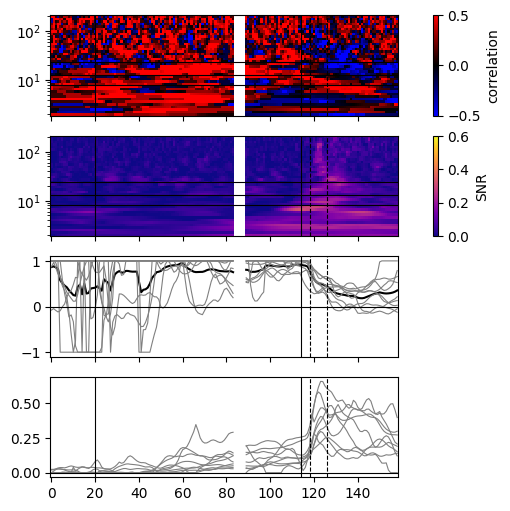

In [80]:
import matplotlib.colors as mcolors

G_spk = np.load(os.path.join(baseDir, pcmDir, f'G_obs.spk.corr_tf.M1.npy'))
cov = G_spk[:, :, 0, 1]
var1 = np.clip(G_spk[:, :, 0, 0], 0, None)
var2 = np.clip(G_spk[:, :, 1, 1], 0, None)
SNR_spk = np.sqrt(var1 * var2)
r_indiv_spk = np.clip(cov / SNR_spk + 1e-12, -1, 1)
r_group_spk = r_indiv_spk.mean(axis=0)

G_lfp = np.load(os.path.join(baseDir, pcmDir, f'G_obs.lfp.corr_tf.M1.npy'))
cov = G_lfp[..., 0, 1]
var1 = np.clip(G_lfp[..., 0, 0], 0, None)
var2 = np.clip(G_lfp[..., 1, 1], 0, None)
SNR_lfp = np.sqrt(var1 * var2)
r_indiv_lfp = np.clip(cov / SNR_lfp + 1e-12, -1, 1)
r_group_lfp = r_indiv_lfp.mean(axis=0)

N = r_indiv_spk.shape[0]
thresh = .1
excl_spk = (SNR_spk > thresh).sum(axis=0) #np.isclose(np.abs(r_indiv_spk), 1).sum(axis=0)
# r_group_spk[excl_spk <= N//2] = np.nan
# r_indiv_spk[:, excl_spk <= N//2] = np.nan

excl_lfp = (SNR_lfp > thresh).sum(axis=0) # np.isclose(np.abs(r_indiv_lfp), 1).sum(axis=0)
#r_group_lfp[excl_lfp <= N//2] = np.nan

fig, axs_ = plt.subplots(4, 2, sharex='col', figsize=(5, 6), gridspec_kw={"width_ratios": [80, 1]} )

axs = axs_[:, 0]
ax_c = axs_[:, 1]

h = axs[0].pcolormesh(t_cue, foi, r_group_lfp[:cuePost].T, vmin=-.5, vmax=.5, cmap=cmap)
axs[0].pcolormesh(t_pert, foi, r_group_lfp[pertPre:].T, vmin=-.5, vmax=.5, cmap=cmap)
k = axs[1].pcolormesh(t_cue, foi, SNR_lfp[:, :cuePost].mean(axis=0).T, vmin=0, vmax=.6, cmap='plasma')
axs[1].pcolormesh(t_pert, foi, SNR_lfp[:, pertPre:].mean(axis=0).T, vmin=0, vmax=.6, cmap='plasma')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[2].plot(t_cue, r_group_spk[:cuePost], color='k')
axs[2].plot(t_pert, r_group_spk[pertPre:], color='k')
axs[2].plot(t_cue, r_indiv_spk[:, :cuePost].T, color='grey', lw=.8)
axs[2].plot(t_pert, r_indiv_spk[:, pertPre:].T, color='grey', lw=.8)
axs[3].plot(t_cue, SNR_spk[:, :cuePost].T, color='grey', lw=.8)
axs[3].plot(t_pert, SNR_spk[:, pertPre:].T, color='grey', lw=.8)

for i in range(2):
    axs[i].axhline(8, color='k', lw='.8')
    axs[i].axhline(13, color='k', lw='.8')
    axs[i].axhline(24, color='k', lw='.8')

for a, ax in enumerate(axs):
    ax.axvline(cueIdx, color='k', lw=.8)
    ax.axvline(pertIdx, color='k', lw=.8)
    ax.axvline(pertIdx+4, color='k', lw=.8, ls='--')
    ax.axvline(pertIdx+12, color='k', lw=.8, ls='--')
    ax.axhline(0, lw=.8, color='k')

axs[2]

fig.colorbar(h, cax=ax_c[0], label='correlation', cmap=cmap)
fig.colorbar(k, cax=ax_c[1], label='SNR', cmap=cmap)
for ax in ax_c[2:]:
    ax.remove()

plt.show()

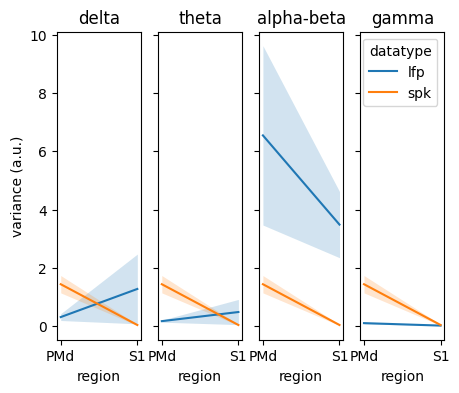

In [81]:
lfp = pd.read_csv(os.path.join(baseDir, pcmDir, 'var_expl.plan.lfp.tsv'), sep='\t')
spk = pd.read_csv(os.path.join(baseDir, pcmDir, 'var_expl.plan.spk.tsv'), sep='\t')
var = pd.concat([lfp, spk], axis=0, ignore_index=True)
var['band'] = var['band'].fillna(0)

fig, axs = plt.subplots(1, 4, figsize=(5, 4), sharex=True, sharey=True)

for f, freq in enumerate(freqs):
    ax = axs[f]
    ax.set_title(freq)
    # aov = pg.mixed_anova(dv='variance', within='datatype', between='region', subject='recording', data=var_)
    # print(f'LFPs frequency band: {freq}------------------------------')
    # print(aov)
    sb.lineplot(ax=axs[f],
                data=var[((var['band']==freq) | (var['band']==0)) & (var['model']=='Cue') & (var['epoch']=='Cue')],
                x='region',
                y='variance',
                hue='datatype',
                errorbar='se',
                err_kws={'lw': 0},
                legend=False if f<len(freqs)-1 else True)

axs[0].set_ylabel('variance (a.u.)')

plt.show()

In [82]:
spk = pd.read_csv(os.path.join(baseDir, pcmDir, 'var_expl.plan.spk.tsv'), sep='\t')
spk = spk[(spk['model']=='Cue') & (spk['epoch']=='Cue')].copy()
x1 = gdf.loc[gdf["region"] == "PMd", 'variance'].dropna().to_numpy()
x2 = gdf.loc[gdf["region"] == "S1",  'variance'].dropna().to_numpy()

res_ = hedges_g(x1, x2)
res = pd.Series(res_)
res['band'] = 'spikes'

lfp = pd.read_csv(os.path.join(baseDir, pcmDir, 'var_expl.plan.lfp.tsv'), sep='\t')
lfp = lfp[lfp["model"] == "Cue"].copy()
rows = []
for band_val, gdf in sub.groupby("band"):
    x1 = gdf.loc[(gdf["region"] == "PMd") & (gdf['model']=='Cue') & (gdf['epoch']=='Cue'), 'variance'].dropna().to_numpy()
    x2 = gdf.loc[(gdf["region"] == "S1") & (gdf['model']=='Cue') & (gdf['epoch']=='Cue'),  'variance'].dropna().to_numpy()
    res_ = pd.Series(hedges_g(x1, x2))
    res_['band'] = band_val
    res = pd.concat([res, res_], axis=1)

res = res.T

NameError: name 'gdf' is not defined

In [141]:
print(res)

         g      se   var_g   ci_low  ci_high        d       J       sp  \
0 -0.98799 0.34790 0.12103 -1.66987 -0.30610 -1.00563 0.98246  5.43185   
1 -0.09328 0.54983 0.30232 -1.17095  0.98439 -0.09911 0.94118  5.59239   
0  0.31955 0.55309 0.30591 -0.76451  1.40360  0.33952 0.94118  9.01886   
0  0.44915 0.55654 0.30974 -0.64168  1.53998  0.47722 0.94118 11.46833   
0 -0.75724 0.56924 0.32404 -1.87296  0.35847 -0.80457 0.94118  1.19972   
0  1.01034 0.58416 0.34124 -0.13461  2.15529  1.07349 0.94118  0.07881   
0 -0.68751 0.56583 0.32016 -1.79653  0.42151 -0.73048 0.94118  0.42829   

        n1       n2  
0 33.00000 12.00000  
1 11.00000  4.00000  
0 11.00000  4.00000  
0 11.00000  4.00000  
0 11.00000  4.00000  
0 11.00000  4.00000  
0 11.00000  4.00000  


In [126]:
# monkey = ['Malfoy', 'Pert']
# roi = 'S1'
# rec = {'Malfoy': [26, 27, 28],
#        'Pert': [15]}
#
# spk = []
# for m in monkey:
#     for r in rec[m]:
#         spk_ = np.load(os.path.join(baseDir, spkDir, m, f'spk_aligned.{roi}-{r}.npy'))
#         spk.append(spk_.mean(axis=(1, 2)).T)
#
# spk = np.array(spk)
# spk = spk.mean(axis=0)
#
# fig, ax = plt.subplots()
# ax.plot(t_cue, spk[:cuePost], color='grey')
# ax.plot(t_pert, spk[pertPre:], color='grey')
# ax.axvline(cueIdx, color='k', lw=.8)
# ax.axvline(pertIdx, color='k', lw=.8)
# ax.set_ylabel('firing rate (Hz)')
# ax.set_xticks([cueIdx, pertIdx])
# ax.set_xticklabels(['Cue', 'Pert'])
# ax.set_title(f'Firing rate ({roi})')
#
# plt.show()

In [127]:
# monkey = ['Malfoy', 'Pert']
# roi = 'S1'
# rec = {'Malfoy': [26, 27, 28],
#        'Pert': [15]}
#
# lfp = []
# for m in monkey:
#     for r in rec[m]:
#         lfp_ = np.load(os.path.join(baseDir, lfpDir, m, f'lfp_aligned.{roi}-{r}.npy'))
#         lfp.append(lfp_.mean(axis=(1, 3)).T)
#
# lfp = np.array(lfp)
# lfp = lfp.mean(axis=0)
#
# fig, ax = plt.subplots()
# ax.axvline(cueIdx, color='k', lw=.8)
# ax.axvline(pertIdx, color='k', lw=.8)
# ax.axhline(8, color='k', lw=.8)
# ax.axhline(13, color='k', lw=.8)
# ax.axhline(24, color='k', lw=.8)
# ax.pcolormesh(t_cue, foi, lfp[:, :cuePost])
# ax.pcolormesh(t_pert, foi, lfp[:, pertPre:])
# ax.set_yscale('log')
# ax.set_ylabel('frequency (Hz)')
# ax.set_xticks([cueIdx, pertIdx])
# ax.set_xticklabels(['Cue', 'Pert'])
# ax.set_title(f'LFPs ({roi})')
#
# plt.show()